In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carrega o Titanic direto da URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [31]:
# Visão geral do dataset
print("Tamanho:", df.shape)
print("\nColunas e tipos:")
print(df.dtypes)
print("\nValores nulos:")
print(df.isnull().sum())
print("\nEstatísticas gerais:")
df.describe()

Tamanho: (891, 12)

Colunas e tipos:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Valores nulos:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Estatísticas gerais:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [32]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True)

# Confirma que não tem mais nulos relevantes
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_2691/163467895.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_2691/163467895.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

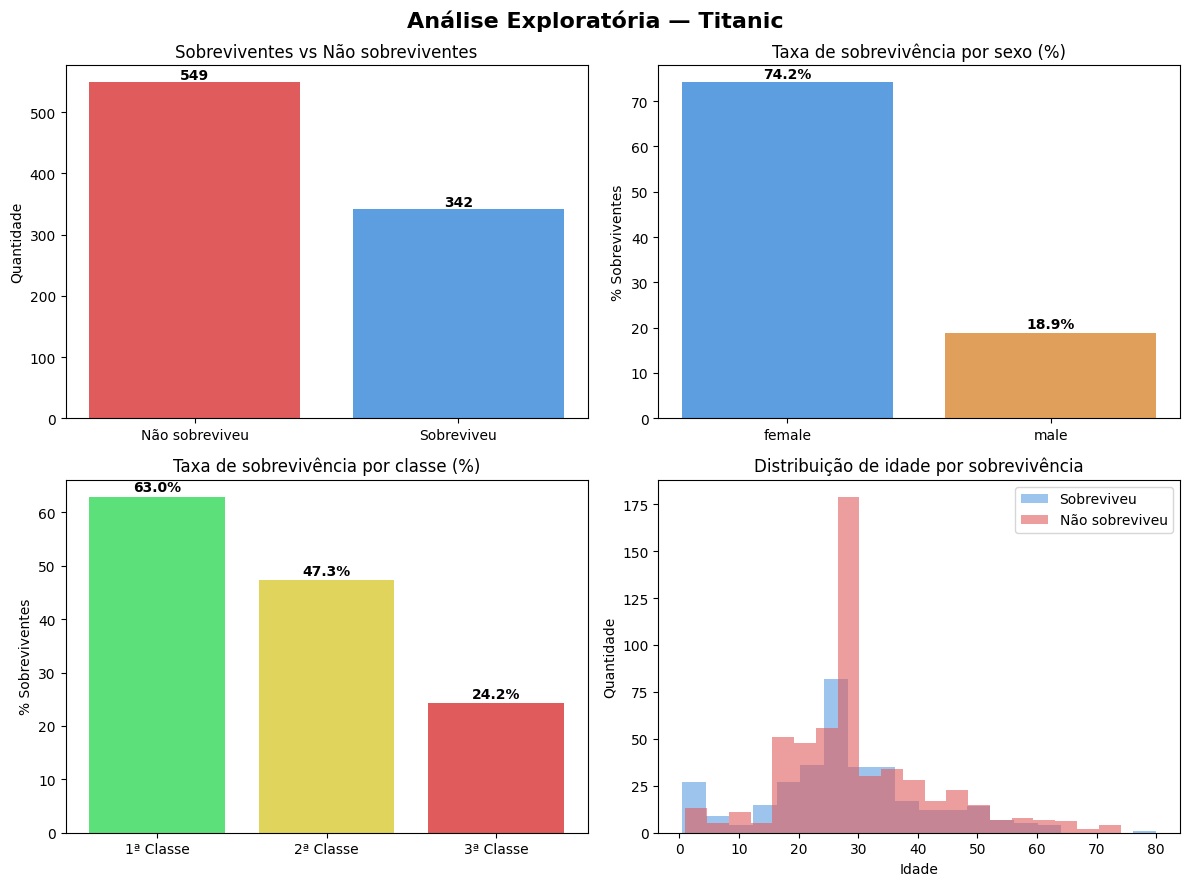

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Análise Exploratória — Titanic', fontsize=16, fontweight='bold')

# 1. Taxa de sobrevivência geral
survival_counts = df['Survived'].value_counts()
axes[0, 0].bar(['Não sobreviveu', 'Sobreviveu'], survival_counts.values, color=['#e05c5c', '#5c9ee0'])
axes[0, 0].set_title('Sobreviventes vs Não sobreviventes')
axes[0, 0].set_ylabel('Quantidade')
for i, v in enumerate(survival_counts.values):
    axes[0, 0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2. Sobrevivência por sexo
survival_sex = df.groupby('Sex')['Survived'].mean() * 100
axes[0, 1].bar(survival_sex.index, survival_sex.values, color=['#5c9ee0', '#e0a05c'])
axes[0, 1].set_title('Taxa de sobrevivência por sexo (%)')
axes[0, 1].set_ylabel('% Sobreviventes')
for i, v in enumerate(survival_sex.values):
    axes[0, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# 3. Sobrevivência por classe
survival_class = df.groupby('Pclass')['Survived'].mean() * 100
axes[1, 0].bar(['1ª Classe', '2ª Classe', '3ª Classe'], survival_class.values, color=['#5ce07a', '#e0d45c', '#e05c5c'])
axes[1, 0].set_title('Taxa de sobrevivência por classe (%)')
axes[1, 0].set_ylabel('% Sobreviventes')
for i, v in enumerate(survival_class.values):
    axes[1, 0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# 4. Distribuição de idade
axes[1, 1].hist(df[df['Survived'] == 1]['Age'], bins=20, alpha=0.6, color='#5c9ee0', label='Sobreviveu')
axes[1, 1].hist(df[df['Survived'] == 0]['Age'], bins=20, alpha=0.6, color='#e05c5c', label='Não sobreviveu')
axes[1, 1].set_title('Distribuição de idade por sobrevivência')
axes[1, 1].set_xlabel('Idade')
axes[1, 1].set_ylabel('Quantidade')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('titanic_analise.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
import os


notebook_url = "https://colab.research.google.com/github/luccasnn/analise-titanic/blob/main/titanic_analysis.ipynb"

readme = """# 🚢 Análise Exploratória — Titanic

Exploração dos dados do Titanic buscando padrões entre quem sobreviveu e quem não sobreviveu.
Cresci assistindo o filme e sempre quis entender se os dados confirmam o que aparece na tela — confirmam.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)]({})

## O que os dados mostram

- **Mulheres sobreviveram muito mais que homens** — a política "mulheres e crianças primeiro" aparece claramente nos números
- **Classe social foi determinante** — passageiros da 1ª classe tiveram taxa de sobrevivência quase 3x maior que os da 3ª
- **A faixa de 25 a 35 anos morreu mais** — provavelmente homens adultos que cederam lugar nos botes

## Tecnologias

- Python 3
- pandas
- matplotlib
- seaborn

## Como rodar

1. Clique no badge **Open in Colab** acima
2. Vá em `Runtime > Run all`
3. Os gráficos e a imagem são gerados automaticamente

## Resultado

![Gráficos da análise](titanic_analise.png)
""".format(notebook_url)

with open('/content/README.md', 'w', encoding='utf-8') as f:
    f.write(readme)

print("README atualizado!")

README atualizado!


In [35]:
from google.colab import files

files.download('README.md')
files.download('titanic_analise.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
import os
print(os.listdir('/content'))

['.config', 'README.md', 'titanic_analise.png', 'sample_data']
